9. Download a real-world dataset containing at least 1000 samples and more than 10
features. Perform exploratory data analysis (EDA) to understand its structure. Apply
Principal Component Analysis (PCA) to reduce dimensionality and analyze variance
explained by principal components. Visualize the dataset using different sets of
principal components and interpret the results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
df=pd.read_csv('/content/House Price India.csv')

In [3]:
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


In [4]:
df.isnull().sum()

,0
id,0
Date,0
number of bedrooms,0
number of bathrooms,0
living area,0
lot area,0
number of floors,0
waterfront present,0
number of views,0
condition of the house,0


In [5]:
df.nunique()

,0
id,14620
Date,241
number of bedrooms,12
number of bathrooms,29
living area,865
lot area,7451
number of floors,6
waterfront present,2
number of views,5
condition of the house,5


In [6]:
df['lot area'].unique()

array([ 9050,  4000,  9480, ...,  3770, 10425,  6621])

In [17]:
df.shape

(14620, 23)

In [7]:
housedata=df.drop(['Date','Postal Code','Lattitude','Longitude','id','number of views','waterfront present'],axis=1)

In [8]:
housedata.head()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Renovation Year,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,5,2.50,3650,9050,2.0,5,10,3370,280,1921,0,2880,5400,2,58,2380000
1,4,2.50,2920,4000,1.5,5,8,1910,1010,1909,0,2470,4000,2,51,1400000
2,5,2.75,2910,9480,1.5,3,8,2910,0,1939,0,2940,6600,1,53,1200000
3,4,2.50,3310,42998,2.0,3,9,3310,0,2001,0,3350,42847,3,76,838000
4,3,2.00,2710,4500,1.5,4,8,1880,830,1929,0,2060,4500,1,51,805000


In [9]:
housedata.describe()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Renovation Year,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,14620.000000,14620.000000,14620.000000,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04
mean,3.379343,2.129583,2098.262996,1.509328e+04,1.502360,3.430506,7.682421,1801.783926,296.479070,1970.926402,90.924008,1996.702257,12753.500068,2.012244,64.950958,5.389322e+05
std,0.938719,0.769934,928.275721,3.791962e+04,0.540239,0.664151,1.175033,833.809963,448.551409,29.493625,416.216661,691.093366,26058.414467,0.817284,8.936008,3.675324e+05
min,1.000000,0.500000,370.000000,5.200000e+02,1.000000,1.000000,4.000000,370.000000,0.000000,1900.000000,0.000000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,3.000000,1.750000,1440.000000,5.010750e+03,1.000000,3.000000,7.000000,1200.000000,0.000000,1951.000000,0.000000,1490.000000,5097.750000,1.000000,57.000000,3.200000e+05
50%,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,3.000000,7.000000,1580.000000,0.000000,1975.000000,0.000000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,4.000000,8.000000,2240.000000,580.000000,1997.000000,0.000000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


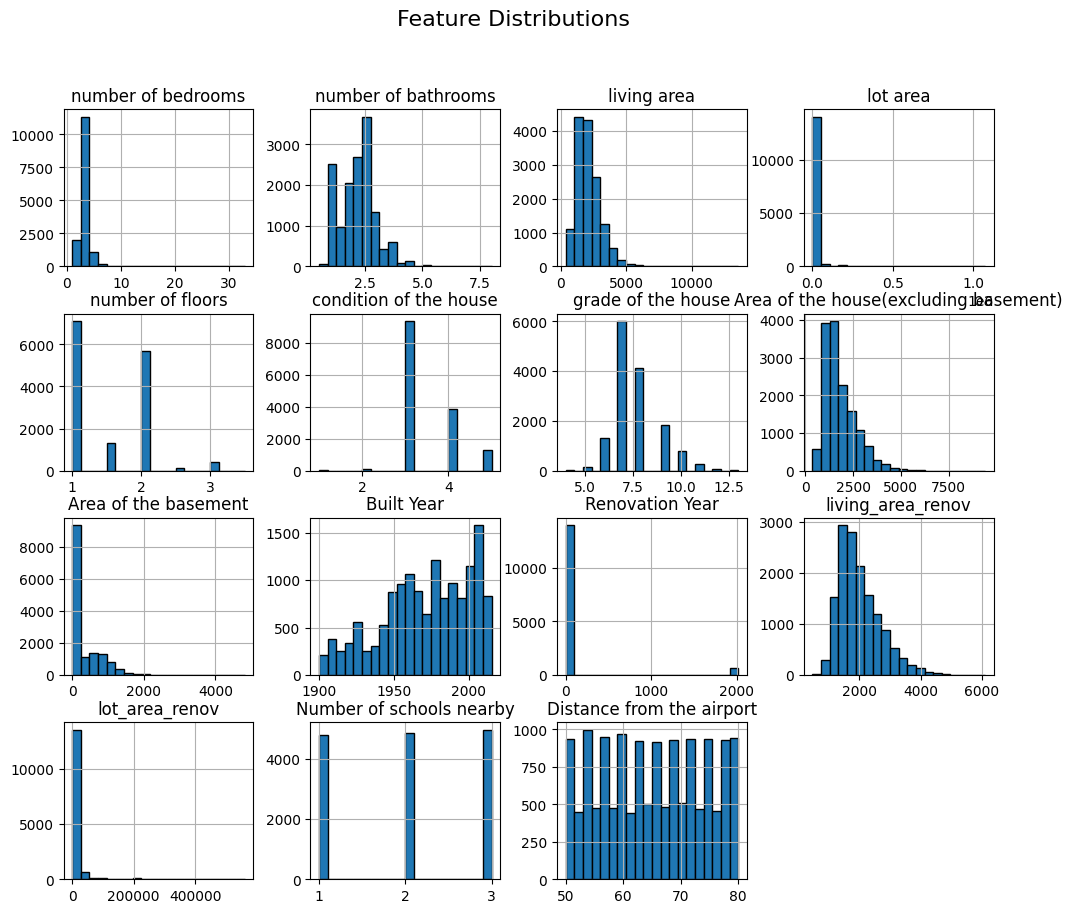

In [10]:
housedata.drop(columns=['Price']).hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

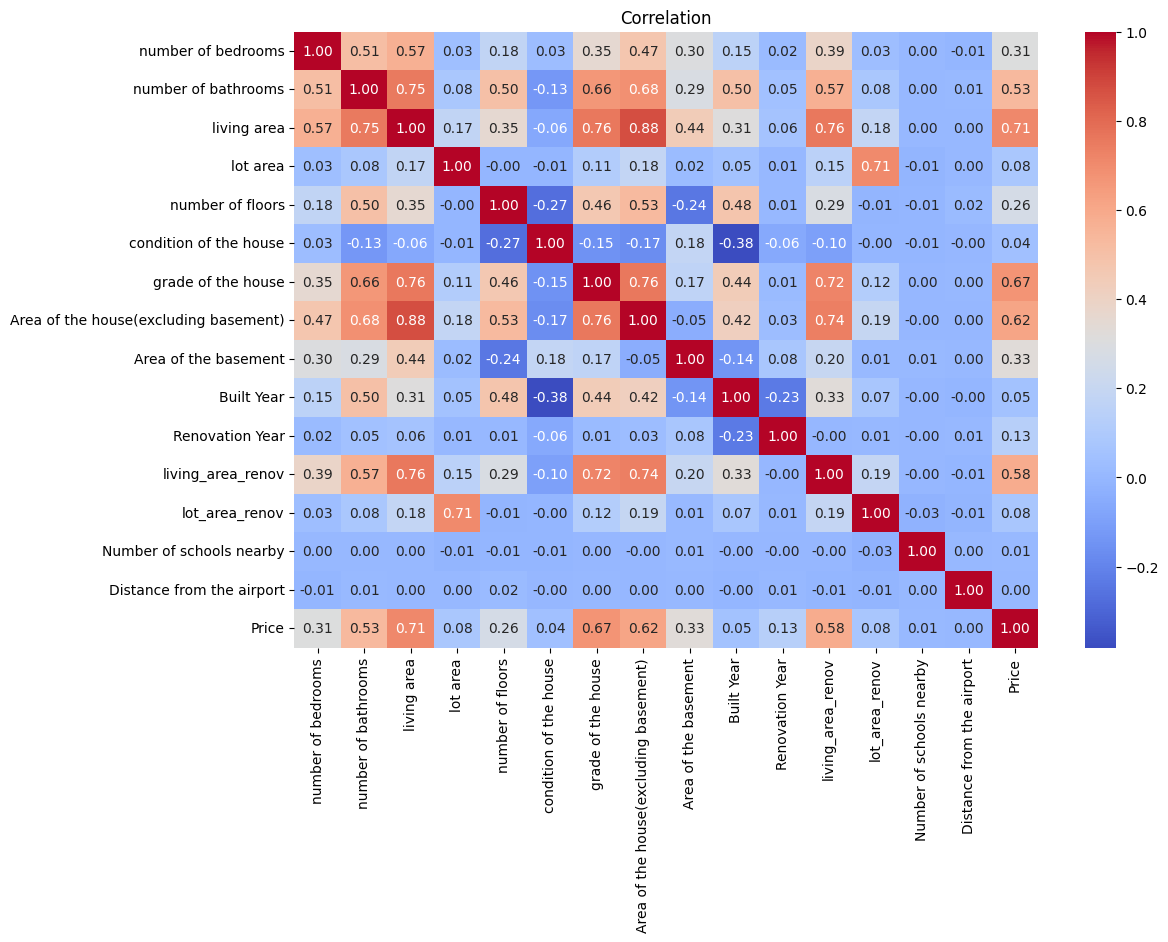

In [11]:
corr=housedata.corr()
corr
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation")
plt.show()


In [12]:
X = housedata.drop(columns=['Price'])
scaler = StandardScaler()
X_scaled =scaler.fit_transform(X)

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [14]:
X_scaled.shape
X_pca.shape


(14620, 2)

In [15]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Price'] = housedata['Price']

<ipython-input-16-e5f04830e36d>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='PC1', y='PC2', data=df_pca, palette='Set1')


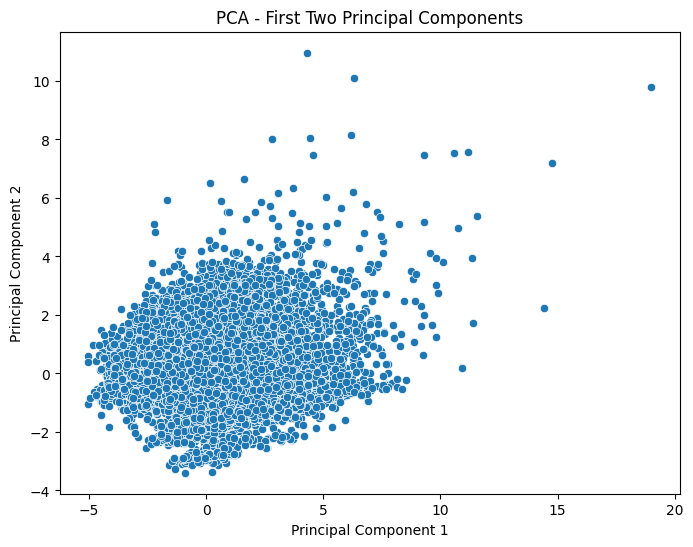

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, palette='Set1')
plt.title("PCA - First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()